## **1. 드라이브 연결**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


# **1D-CNN AE**

## **2. 파라미터 설정, 데이터 로드, 데이터셋 분리**

- 모든 실험을 통합하여 데이터셋 구성

In [2]:
# ==========================================
# 1. 라이브러리 및 환경 설정
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import warnings


warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. 통합 데이터 전처리 (Unified Dataset)
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"
if os.path.exists(file_path):
    df = pd.read_excel(file_path) if file_path.endswith('.xlsx') else pd.read_csv(file_path)
else:
    df = pd.DataFrame()

sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):
    data_values = df_target[sensor_cols].values
    if is_train:
        if scaler is None: scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        data_scaled = scaler.transform(data_values)

    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences, all_wafer_ids = [], []
    for wafer in df_scaled[wafer_col].unique():
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values
        if len(wafer_data) < seq_len: continue
        for i in range(len(wafer_data) - seq_len + 1):
            all_sequences.append(wafer_data[i : i + seq_len])
            all_wafer_ids.append(wafer)

    if len(all_sequences) == 0: return np.array([]), np.array([]), scaler
    return np.array(all_sequences), np.array(all_wafer_ids), scaler



# --- 데이터 통합 및 분할 ---
datasets = {}
target_experiments = ['l29', 'l31', 'l33']
SEQ_LEN = 32
TRAIN_RATIO = 0.7

print(f"🚀 Creating Unified Dataset from: {target_experiments}")

# 통합 데이터 필터링
combined_mask = df['Wafer_ID'].str.contains('|'.join(target_experiments), case=False, na=False)
combined_df = df[combined_mask]

# ID 셔플 및 분할
all_normal_ids = combined_df[combined_df['Label'] == 'Normal']['Wafer_ID'].unique()
all_fault_ids = combined_df[combined_df['Label'] == 'Fault']['Wafer_ID'].unique()

np.random.seed(42)
np.random.shuffle(all_normal_ids)

n_train = int(len(all_normal_ids) * TRAIN_RATIO)
train_ids = all_normal_ids[:n_train]
test_norm_ids = all_normal_ids[n_train:]

# 데이터프레임 분할
df_train = combined_df[combined_df['Wafer_ID'].isin(train_ids)]
df_test_norm = combined_df[combined_df['Wafer_ID'].isin(test_norm_ids)]
df_test_fault = combined_df[combined_df['Wafer_ID'].isin(all_fault_ids)]

# 시퀀스 생성
X_train, ids_train, global_scaler = create_sequences_with_ids(df_train, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True)
X_test_norm, ids_test_norm, _ = create_sequences_with_ids(df_test_norm, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)
X_test_fault, ids_test_fault, _ = create_sequences_with_ids(df_test_fault, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)

# 사용자가 제공한 get_data_loaders 함수가 작동하도록 딕셔너리에 저장
datasets['Unified'] = {
    'X_train': X_train,
    'ids_train': ids_train,
    'X_test_norm': X_test_norm,
    'ids_test_norm': ids_test_norm,
    'X_test_fault': X_test_fault,
    'ids_test_fault': ids_test_fault
}
print("✅ Unified Dataset Prepared.")

Using device: cuda
🚀 Creating Unified Dataset from: ['l29', 'l31', 'l33']
✅ Unified Dataset Prepared.


## **3. 함수 선언**

In [3]:
# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault)
    else:
        test_fault_tensor = torch.FloatTensor([])

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    preds = (scores > threshold).astype(int)
    f1 = f1_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    visualize_results(model_name, exp_id, scores, labels, threshold)
    return roc_auc, f1

## **4. 모델 구현**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# ==========================================
# 1. 1D-CNN AE 모델 구조 (논문 기반 LRE 적용)
# ==========================================
class CNN1D_AE(nn.Module):
    def __init__(self, num_sensors=19, seq_len=32, latent_dim=8):
        super(CNN1D_AE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=num_sensors, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=latent_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=latent_dim, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=32, out_channels=num_sensors, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # (Batch, Seq_Len, Sensors) -> (Batch, Sensors, Seq_Len)
        x = x.transpose(1, 2)
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        # (Batch, Sensors, Seq_Len) -> (Batch, Seq_Len, Sensors)
        return reconstructed.transpose(1, 2)

# ==========================================
# 2. 학습 및 추론 함수 (MAE Loss 및 LRE 적용)
# ==========================================
def train_1d_cnn_ae(model, train_loader, optimizer, epoch, device):
    model.train()
    total_loss = 0
    criterion = nn.L1Loss() # MAE Loss

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, data) # AE는 자기 자신이 타겟

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def calculate_window_scores_1d_cnn(model, data_tensor, device, batch_size=32):
    model.eval()
    all_scores = []
    criterion = nn.L1Loss(reduction='none')

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            output = model(data)

            loss_element = criterion(output, data)

            # Localised Reconstruction Error (LRE)
            channel_errors = loss_element.mean(dim=1) # 센서별 평균
            score_window, _ = channel_errors.max(dim=1) # 가장 높은 에러를 윈도우 스코어로

            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

## **5. 학습 및 추론**

Using device: cuda

>>> Running 1D-CNN AE on Experiment: Unified

📊 [Data Setup] Experiment: Unified
Training started...
Epoch [10] Loss: 0.0828
Epoch [20] Loss: 0.0708
Epoch [30] Loss: 0.0696
Epoch [40] Loss: 0.0690
Epoch [50] Loss: 0.0684
Calculating Train Scores for Thresholding...
   * Train Score Mean: 0.2472, Std: 0.0417
   * Fixed 3-Sigma Threshold: 0.3724
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [1D-CNN AE (Unified) - Unified] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.7431
   - F1-Score       : 0.6452 (at Fixed Threshold: 0.372427)


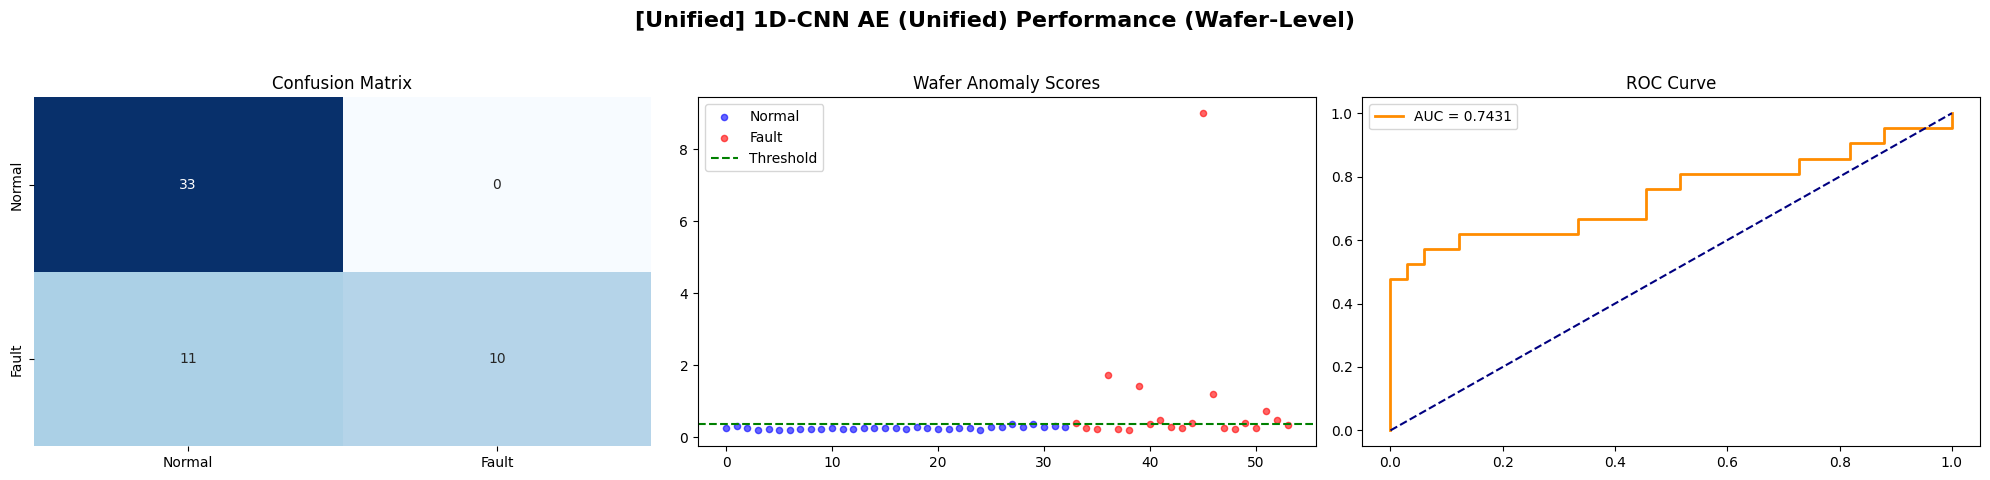


✅ All experiments finished.
{'Unified': {'AUC': np.float64(0.7431457431457431), 'F1': 0.6451612903225806}}


In [5]:
# ==========================================
# 5. 메인 실행 루프 (Unified 1D-CNN AE)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1D-CNN AE 맞춤 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
LATENT_DIM = 8  # D_MODEL 및 RESOLUTION 대신 사용
SIGMA_MULTIPLIER = 3

results = {}
target_experiments = ['Unified']

for exp_id in target_experiments:
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n>>> Running 1D-CNN AE on Experiment: {exp_id}")

    # 1. 데이터 로드
    train_loader, (test_norm, ids_norm), (test_fault, ids_fault) = get_data_loaders(exp_id, datasets, BATCH_SIZE)

    # 2. 모델 초기화
    num_sensors = test_norm.shape[2]
    seq_len_input = test_norm.shape[1]

    model = CNN1D_AE(
        num_sensors=num_sensors,
        seq_len=seq_len_input, # Next-token 예측이 아니므로 길이를 자르지 않음
        latent_dim=LATENT_DIM
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 3. 학습
    print("Training started...")
    for epoch in range(NUM_EPOCHS):
        train_1d_cnn_ae(model, train_loader, optimizer, epoch, device)

    # -----------------------------------------------------------
    # 4. 임계값(Threshold) 설정
    # -----------------------------------------------------------
    print("Calculating Train Scores for Thresholding...")
    train_tensor = train_loader.dataset.tensors[0]
    train_window_scores = calculate_window_scores_1d_cnn(model, train_tensor, device, BATCH_SIZE)

    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)

    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    # -----------------------------------------------------------
    # 5. 추론 (Test Data Window Score)
    # -----------------------------------------------------------
    print("Calculating Test Window Scores...")
    norm_window_scores = calculate_window_scores_1d_cnn(model, test_norm, device, BATCH_SIZE)

    if len(test_fault) > 0:
        fault_window_scores = calculate_window_scores_1d_cnn(model, test_fault, device, BATCH_SIZE)
    else:
        fault_window_scores = np.array([])

    # -----------------------------------------------------------
    # 6. 집계 (Wafer Aggregation)
    # -----------------------------------------------------------
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    # -----------------------------------------------------------
    # 7. 평가
    # -----------------------------------------------------------
    auc_score, f1 = evaluate_performance_fixed_threshold(
        "1D-CNN AE (Unified)", exp_id, final_scores, final_labels, fixed_threshold
    )
    results[exp_id] = {'AUC': auc_score, 'F1': f1}

print("\n✅ All experiments finished.")
print(results)

# **TRACE-GPT**

## **2. 파라미터 설정, 데이터 로드, 데이터셋 분리**

- 모든 실험을 통합하여 데이터셋 구성

In [6]:
# ==========================================
# 1. 라이브러리 및 환경 설정
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import warnings


warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. 통합 데이터 전처리 (Unified Dataset)
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"
if os.path.exists(file_path):
    df = pd.read_excel(file_path) if file_path.endswith('.xlsx') else pd.read_csv(file_path)
else:
    df = pd.DataFrame()

sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):
    data_values = df_target[sensor_cols].values
    if is_train:
        if scaler is None: scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        data_scaled = scaler.transform(data_values)

    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences, all_wafer_ids = [], []
    for wafer in df_scaled[wafer_col].unique():
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values
        if len(wafer_data) < seq_len: continue
        for i in range(len(wafer_data) - seq_len + 1):
            all_sequences.append(wafer_data[i : i + seq_len])
            all_wafer_ids.append(wafer)

    if len(all_sequences) == 0: return np.array([]), np.array([]), scaler
    return np.array(all_sequences), np.array(all_wafer_ids), scaler



# --- 데이터 통합 및 분할 ---
datasets = {}
target_experiments = ['l29', 'l31', 'l33']
SEQ_LEN = 32
TRAIN_RATIO = 0.7

print(f"🚀 Creating Unified Dataset from: {target_experiments}")

# 통합 데이터 필터링
combined_mask = df['Wafer_ID'].str.contains('|'.join(target_experiments), case=False, na=False)
combined_df = df[combined_mask]

# ID 셔플 및 분할
all_normal_ids = combined_df[combined_df['Label'] == 'Normal']['Wafer_ID'].unique()
all_fault_ids = combined_df[combined_df['Label'] == 'Fault']['Wafer_ID'].unique()

np.random.seed(42)
np.random.shuffle(all_normal_ids)

n_train = int(len(all_normal_ids) * TRAIN_RATIO)
train_ids = all_normal_ids[:n_train]
test_norm_ids = all_normal_ids[n_train:]

# 데이터프레임 분할
df_train = combined_df[combined_df['Wafer_ID'].isin(train_ids)]
df_test_norm = combined_df[combined_df['Wafer_ID'].isin(test_norm_ids)]
df_test_fault = combined_df[combined_df['Wafer_ID'].isin(all_fault_ids)]

# 시퀀스 생성
X_train, ids_train, global_scaler = create_sequences_with_ids(df_train, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True)
X_test_norm, ids_test_norm, _ = create_sequences_with_ids(df_test_norm, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)
X_test_fault, ids_test_fault, _ = create_sequences_with_ids(df_test_fault, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)

# 사용자가 제공한 get_data_loaders 함수가 작동하도록 딕셔너리에 저장
datasets['Unified'] = {
    'X_train': X_train,
    'ids_train': ids_train,
    'X_test_norm': X_test_norm,
    'ids_test_norm': ids_test_norm,
    'X_test_fault': X_test_fault,
    'ids_test_fault': ids_test_fault
}
print("✅ Unified Dataset Prepared.")

Using device: cuda
🚀 Creating Unified Dataset from: ['l29', 'l31', 'l33']
✅ Unified Dataset Prepared.


## **3. 함수 정의**

In [7]:
# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault)
    else:
        test_fault_tensor = torch.FloatTensor([])

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    preds = (scores > threshold).astype(int)
    f1 = f1_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    visualize_results(model_name, exp_id, scores, labels, threshold)
    return roc_auc, f1

## **4. 모델 구현**

In [8]:
# ==========================================
# 3. 모델 정의 (TRACE-GPT Fixed Version - 이전 변수명/구조 유지)
# ==========================================
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=64, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        # TCN 4층 (Receptive Field 확보)
        tcn_channels = [d_model] * 4

        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1, # +1 for Time Index
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        # ✅ [수정 완수] Data Leakage 방지를 위한 TransformerEncoder 사용
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()

        # Positional Embedding
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)

        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)

        # ✅ [수정 완수] Encoder에 is_causal=True 적용 및 mask 전달
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)

        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits


# ==========================================
# 4. 학습 및 추론 함수 (이전 함수명 완벽 유지)
# ==========================================
def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx

def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Input(0~T-1) -> Target(1~T)
        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)

        loss = criterion(
            output_logits.reshape(-1, resolution),
            target_idx.reshape(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]
            target_seq = data[:, 1:, :]
            target_idx = quantize_data(target_seq, resolution)

            output_logits = model(input_seq)

            loss_element = criterion(
                output_logits.reshape(-1, resolution),
                target_idx.reshape(-1)
            )
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            # Window별 평균 Loss
            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

## **5. 학습 및 추론**

Using device: cuda

>>> Running TRACE-GPT (Fixed) on Experiment: Unified

📊 [Data Setup] Experiment: Unified
Training started...
Epoch [2] Loss: 2.4825
Epoch [4] Loss: 2.2595
Epoch [6] Loss: 2.1918
Epoch [8] Loss: 2.1292
Epoch [10] Loss: 2.0887
Epoch [12] Loss: 2.0664
Epoch [14] Loss: 2.0584
Epoch [16] Loss: 2.0346
Epoch [18] Loss: 2.0381
Epoch [20] Loss: 2.0106
Epoch [22] Loss: 2.0049
Epoch [24] Loss: 1.9807
Epoch [26] Loss: 1.9712
Epoch [28] Loss: 1.9569
Epoch [30] Loss: 1.9484
Epoch [32] Loss: 1.9375
Epoch [34] Loss: 1.9260
Epoch [36] Loss: 1.9197
Epoch [38] Loss: 1.9062
Epoch [40] Loss: 1.8909
Epoch [42] Loss: 1.8791
Epoch [44] Loss: 1.8700
Epoch [46] Loss: 1.8646
Epoch [48] Loss: 1.8482
Epoch [50] Loss: 1.8372
Calculating Train Scores for Thresholding...
   * Train Score Mean: 2.0770, Std: 0.0481
   * Fixed 3-Sigma Threshold: 2.2214
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [TRACE-GPT(Unified) - Unified] Wafer-Level Summary (Unsupervised)
   - AUROC    

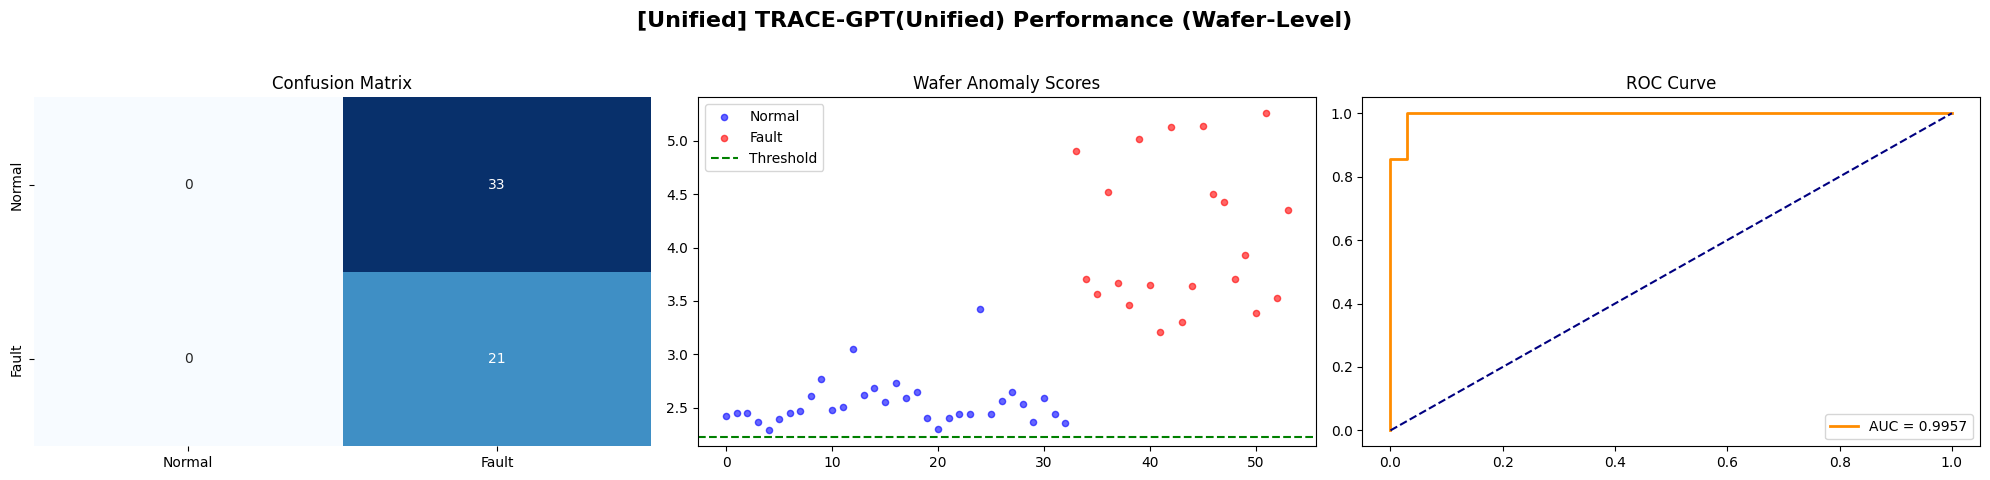


✅ All experiments finished.
{'Unified': {'AUC': np.float64(0.9956709956709957), 'F1': 0.56}}


In [9]:
# ==========================================
# 5. 메인 실행 루프 (Unified Version)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 하이퍼파라미터 (이전 명칭 유지)
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
D_MODEL = 64
RESOLUTION = 100
SIGMA_MULTIPLIER = 3 # ✅ 변수 적용 완료

results = {}
# 개별 실험 ID 대신 전처리에서 만든 통합 데이터셋 키 'Unified'를 사용합니다.
target_experiments = ['Unified']

for exp_id in target_experiments:
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n>>> Running TRACE-GPT (Fixed) on Experiment: {exp_id}")

    # 1. 데이터 로드
    train_loader, (test_norm, ids_norm), (test_fault, ids_fault) = get_data_loaders(exp_id, datasets, BATCH_SIZE)

    # 2. 모델 초기화
    num_sensors = test_norm.shape[2]
    seq_len_input = test_norm.shape[1]

    model = TRACE_GPT(
        num_sensors=num_sensors,
        seq_len=seq_len_input - 1,
        d_model=D_MODEL,
        resolution=RESOLUTION
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 3. 학습
    print("Training started...")
    for epoch in range(NUM_EPOCHS):
        train_trace_gpt(model, train_loader, optimizer, epoch, device, RESOLUTION)

    # -----------------------------------------------------------
    # 4. 임계값(Threshold) 설정 (Train 데이터 통계치 활용 - 비지도 학습)
    # -----------------------------------------------------------
    print("Calculating Train Scores for Thresholding...")
    train_tensor = train_loader.dataset.tensors[0]
    train_window_scores = calculate_window_scores(model, train_tensor, device, BATCH_SIZE, RESOLUTION)

    # Train Score를 Wafer 단위로 집계
    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    # Train 분포의 평균과 표준편차 계산
    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)

    # ✅ [수정 완수] SIGMA_MULTIPLIER 변수 적용
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    # -----------------------------------------------------------
    # 5. 추론 (Test Data Window Score)
    # -----------------------------------------------------------
    print("Calculating Test Window Scores...")
    norm_window_scores = calculate_window_scores(model, test_norm, device, BATCH_SIZE, RESOLUTION)

    if len(test_fault) > 0:
        fault_window_scores = calculate_window_scores(model, test_fault, device, BATCH_SIZE, RESOLUTION)
    else:
        fault_window_scores = np.array([])

    # -----------------------------------------------------------
    # 6. 집계 (Wafer Aggregation)
    # -----------------------------------------------------------
    print("Aggregating Test Wafer Scores...")
    _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
    norm_labels = np.zeros(len(norm_wafer_scores))

    if len(fault_window_scores) > 0:
        _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
        fault_labels = np.ones(len(fault_wafer_scores))
    else:
        fault_wafer_scores = np.array([])
        fault_labels = np.array([])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([norm_labels, fault_labels])

    # -----------------------------------------------------------
    # 7. 평가 (✅ 고정 임계값 전용 평가 함수 사용)
    # -----------------------------------------------------------
    auc_score, f1 = evaluate_performance_fixed_threshold(
        "TRACE-GPT(Unified)", exp_id, final_scores, final_labels, fixed_threshold
    )
    results[exp_id] = {'AUC': auc_score, 'F1': f1}

print("\n✅ All experiments finished.")
print(results)

# **VTimesNet**

## **2. 파라미터 설정, 데이터 로드, 데이터셋 분리**

- 모든 실험을 통합하여 데이터셋 구성

In [10]:
# ==========================================
# 1. 라이브러리 및 환경 설정
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import warnings


warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. 통합 데이터 전처리 (Unified Dataset)
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"
if os.path.exists(file_path):
    df = pd.read_excel(file_path) if file_path.endswith('.xlsx') else pd.read_csv(file_path)
else:
    df = pd.DataFrame()

sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):
    data_values = df_target[sensor_cols].values
    if is_train:
        if scaler is None: scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        data_scaled = scaler.transform(data_values)

    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences, all_wafer_ids = [], []
    for wafer in df_scaled[wafer_col].unique():
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values
        if len(wafer_data) < seq_len: continue
        for i in range(len(wafer_data) - seq_len + 1):
            all_sequences.append(wafer_data[i : i + seq_len])
            all_wafer_ids.append(wafer)

    if len(all_sequences) == 0: return np.array([]), np.array([]), scaler
    return np.array(all_sequences), np.array(all_wafer_ids), scaler



# --- 데이터 통합 및 분할 ---
datasets = {}
target_experiments = ['l29', 'l31', 'l33']
SEQ_LEN = 32
TRAIN_RATIO = 0.7

print(f"🚀 Creating Unified Dataset from: {target_experiments}")

# 통합 데이터 필터링
combined_mask = df['Wafer_ID'].str.contains('|'.join(target_experiments), case=False, na=False)
combined_df = df[combined_mask]

# ID 셔플 및 분할
all_normal_ids = combined_df[combined_df['Label'] == 'Normal']['Wafer_ID'].unique()
all_fault_ids = combined_df[combined_df['Label'] == 'Fault']['Wafer_ID'].unique()

np.random.seed(42)
np.random.shuffle(all_normal_ids)

n_train = int(len(all_normal_ids) * TRAIN_RATIO)
train_ids = all_normal_ids[:n_train]
test_norm_ids = all_normal_ids[n_train:]

# 데이터프레임 분할
df_train = combined_df[combined_df['Wafer_ID'].isin(train_ids)]
df_test_norm = combined_df[combined_df['Wafer_ID'].isin(test_norm_ids)]
df_test_fault = combined_df[combined_df['Wafer_ID'].isin(all_fault_ids)]

# 시퀀스 생성
X_train, ids_train, global_scaler = create_sequences_with_ids(df_train, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True)
X_test_norm, ids_test_norm, _ = create_sequences_with_ids(df_test_norm, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)
X_test_fault, ids_test_fault, _ = create_sequences_with_ids(df_test_fault, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=global_scaler, is_train=False)

# 사용자가 제공한 get_data_loaders 함수가 작동하도록 딕셔너리에 저장
datasets['Unified'] = {
    'X_train': X_train,
    'ids_train': ids_train,
    'X_test_norm': X_test_norm,
    'ids_test_norm': ids_test_norm,
    'X_test_fault': X_test_fault,
    'ids_test_fault': ids_test_fault
}
print("✅ Unified Dataset Prepared.")

Using device: cuda
🚀 Creating Unified Dataset from: ['l29', 'l31', 'l33']
✅ Unified Dataset Prepared.


## **3. 함수 정의**

In [11]:
# ==========================================
# 3. 유틸리티 함수 (데이터 로드, 집계, 시각화)
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault)
    else:
        test_fault_tensor = torch.FloatTensor([])

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    preds = (scores > threshold).astype(int)
    f1 = f1_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    visualize_results(model_name, exp_id, scores, labels, threshold)
    return roc_auc, f1

## **4. 모델 구현**

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# ==========================================
# 3. 모델 정의 (V-TimesNet: Vision-Augmented TimesNet)
# ==========================================

class DCM(nn.Module):
    """Dilated Convolutional Module: 팽창률 2, 커널 크기 {1..6} 병렬 적용 [cite: 120, 127]"""
    def __init__(self, in_channels):
        super(DCM, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, in_channels, kernel_size=k, padding='same', dilation=2)
            for k in range(1, 7)
        ])
    def forward(self, x):
        return [conv(x) for conv in self.convs]

class GLGM(nn.Module):
    """Global-Local-Global Fusion Module: 양방향 정보 융합 [cite: 170, 172]"""
    def __init__(self, channels):
        super(GLGM, self).__init__()
        self.td_convs = nn.ModuleList([nn.Conv2d(channels, channels, 3, padding=1) for _ in range(5)])
        self.bu_convs = nn.ModuleList([nn.Conv2d(channels, channels, 3, padding=1) for _ in range(5)])
    def forward(self, features):
        hat_F = [None] * 6
        hat_F[5] = features[5]
        for i in range(4, -1, -1):
            hat_F[i] = self.td_convs[i](features[i] + hat_F[i+1])
        R = [None] * 6
        R[0] = hat_F[0]
        for i in range(1, 6):
            R[i] = self.bu_convs[i-1](hat_F[i] + R[i-1])
        return torch.cat(R, dim=1)

class CBAM(nn.Module):
    """Convolutional Block Attention Module: 채널/공간 어텐션 [cite: 184, 185]"""
    def __init__(self, channels):
        super(CBAM, self).__init__()
        self.ca = nn.Sequential(
            nn.Conv2d(channels, channels // 2, 1, bias=False), nn.ReLU(),
            nn.Conv2d(channels // 2, channels, 1, bias=False), nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(2, 1, 7, padding=3, bias=False), nn.Sigmoid()
        )
    def forward(self, x):
        x = x * self.ca(F.adaptive_avg_pool2d(x, 1) + F.adaptive_max_pool2d(x, 1))
        sa_in = torch.cat([x.mean(1, True), x.max(1, True)[0]], 1)
        return x * self.sa(sa_in)

class TimesPlusBlock(nn.Module):
    """V-TimesNet 핵심 블록: 1D <-> 2D 변환 및 비전 모듈 적용 [cite: 83, 96]"""
    def __init__(self, d_model, k=3):
        super(TimesPlusBlock, self).__init__()
        self.k = k
        self.dcm, self.glgm = DCM(d_model), GLGM(d_model)
        self.cbam = CBAM(d_model * 6)
        self.reduction = nn.Conv2d(d_model * 6, d_model, 1)

    def forward(self, x):
        B, C, T = x.size()
        topk_ampls, topk_indices = torch.topk(torch.abs(torch.fft.rfft(x, dim=-1)).mean([0, 1]), k=self.k)
        res = []
        for idx in topk_indices:
            period = T // idx.item() if idx.item() != 0 else 1
            pad = (period - T % period) % period
            x_2d = F.pad(x, (0, pad)).view(B, C, -1, period)
            out_2d = self.reduction(self.cbam(self.glgm(self.dcm(x_2d))))
            res.append(out_2d.view(B, C, -1)[..., :T])

        weights = torch.softmax(topk_ampls, -1).view(1, 1, 1, -1)
        return torch.sum(torch.stack(res, -1) * weights, -1) + x

class VTimesNet(nn.Module):
    """전체 V-TimesNet 아키텍처 [cite: 72, 75]"""
    def __init__(self, n_features, d_model=64, k=3, num_layers=3, fcn_dim=16):
        super(VTimesNet, self).__init__()
        self.embedding = nn.Linear(n_features, d_model)
        self.layers = nn.ModuleList([TimesPlusBlock(d_model, k=k) for _ in range(num_layers)])
        self.projection = nn.Sequential(nn.Linear(d_model, fcn_dim), nn.GELU(), nn.Linear(fcn_dim, n_features))

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        for layer in self.layers: x = layer(x)
        return self.projection(x.permute(0, 2, 1))

# ==========================================
# 4. 학습 및 추론 함수 (V-TimesNet용 MSE 기반 수정)
# ==========================================

def train_vtimesnet(model, train_loader, optimizer, epoch, device):
    model.train()
    total_loss = 0
    criterion = nn.MSELoss() # 재구성을 위한 MSE Loss 사용

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}] Reconstruction Loss: {avg_loss:.6f}")
    return avg_loss

def calculate_window_scores(model, data_tensor, device, batch_size=32):
    model.eval()
    all_scores = []
    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            output = model(data)
            # 윈도우별 평균 제곱 오차(MSE)를 이상치 점수로 사용
            score_window = torch.mean((data - output)**2, dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

## **5. 학습 및 추론**


>>> Running V-TimesNet on Unified Dataset

📊 [Data Setup] Experiment: Unified
Training started...
Epoch [10] Reconstruction Loss: 0.009754
Epoch [20] Reconstruction Loss: 0.001632
Epoch [30] Reconstruction Loss: 0.000986
Epoch [40] Reconstruction Loss: 0.000594
Epoch [50] Reconstruction Loss: 0.000533
Calculating Train Scores for Thresholding...
   * Fixed 3-Sigma Threshold: 0.0014
Calculating Test Scores...

📌 [V-TimesNet(Unified) - Unified] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.8759
   - F1-Score       : 0.7778 (at Fixed Threshold: 0.001431)


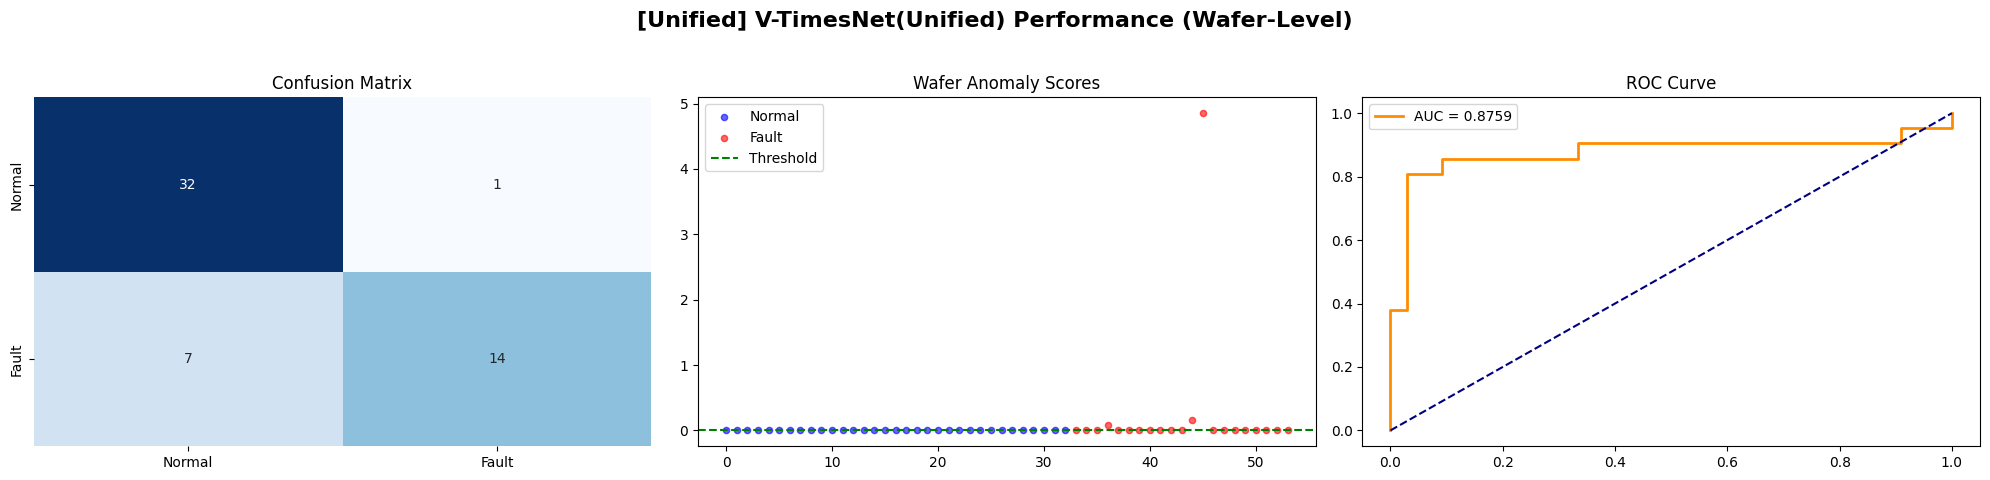


✅ Unified experiment finished.
{'Unified': {'AUC': np.float64(0.8759018759018758), 'F1': 0.7777777777777778}}


In [13]:
# ==========================================
# 5. 메인 실행 루프 (Unified Version)
# ==========================================
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
D_MODEL = 64
TOP_K = 3
SIGMA_MULTIPLIER = 3

results = {}
target_experiments = ['Unified']

for exp_id in target_experiments:
    if exp_id not in datasets: continue

    print(f"\n>>> Running V-TimesNet on Unified Dataset")

    # 1. 데이터 로드
    train_loader, (test_norm, ids_norm), (test_fault, ids_fault) = get_data_loaders(exp_id, datasets, BATCH_SIZE)

    # 2. 모델 초기화 (재구성 모델이므로 seq_len은 입력과 동일하게 설정)
    num_sensors = test_norm.shape[2]
    model = VTimesNet(n_features=num_sensors, d_model=D_MODEL, k=TOP_K).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 3. 학습
    print("Training started...")
    for epoch in range(NUM_EPOCHS):
        train_vtimesnet(model, train_loader, optimizer, epoch, device)

    # 4. 임계값(Threshold) 설정
    print("Calculating Train Scores for Thresholding...")
    train_tensor = train_loader.dataset.tensors[0]
    train_window_scores = calculate_window_scores(model, train_tensor, device, BATCH_SIZE)
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, datasets[exp_id]['ids_train'], method='max')

    train_mean, train_std = np.mean(train_wafer_scores), np.std(train_wafer_scores)
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    # 5. 추론 및 집계
    print("Calculating Test Scores...")
    norm_scores = calculate_window_scores(model, test_norm, device, BATCH_SIZE)
    fault_scores = calculate_window_scores(model, test_fault, device, BATCH_SIZE) if len(test_fault) > 0 else np.array([])

    _, norm_wafer_scores = aggregate_wafer_scores(norm_scores, ids_norm, method='max')
    _, fault_wafer_scores = aggregate_wafer_scores(fault_scores, ids_fault, method='max') if len(fault_scores) > 0 else ([], [])

    final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
    final_labels = np.concatenate([np.zeros(len(norm_wafer_scores)), np.ones(len(fault_wafer_scores))])

    # 6. 평가
    auc_score, f1 = evaluate_performance_fixed_threshold("V-TimesNet(Unified)", exp_id, final_scores, final_labels, fixed_threshold)
    results[exp_id] = {'AUC': auc_score, 'F1': f1}

print("\n✅ Unified experiment finished.")
print(results)